# Lev week 2

Лучшая конфигурация Дениса: Test 2.

- `window_size = 100`
- исключаем `sensor_11`
- модель: `RandomForestRegressor`


In [1]:
import time

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

train_df = pd.read_csv(
    "CMAPSSData/train_FD001.txt", sep=r"\s+", header=None, names=columns
)
test_df = pd.read_csv(
    "CMAPSSData/test_FD001.txt", sep=r"\s+", header=None, names=columns
)
rul_test_df = pd.read_csv(
    "CMAPSSData/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
)

target_col = "Remaining Useful Life"
train_df[target_col] = (
    train_df["unit_id"].map(train_df.groupby("unit_id")["cycle"].max())
    - train_df["cycle"]
)

feature_cols = [
    col
    for col in train_df.columns
    if col.startswith("op_setting_") or col.startswith("sensor_")
]

In [3]:
window_size = 100
excluded_sensor_cols = ["sensor_11"]
window_base_feature_cols = [
    col for col in feature_cols if col not in excluded_sensor_cols
]

rf_params = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 3,
    "min_samples_split": 5,
    "random_state": 42,
    "n_jobs": -1,
}

In [4]:
def build_lag_window_features(
    source_df, selected_feature_cols, include_target=False, require_full_window=False
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    first_values = sorted_df.groupby("unit_id")[selected_feature_cols].transform(
        "first"
    )
    lagged_parts = []

    for lag in range(window_size):
        shifted = sorted_df.groupby("unit_id")[selected_feature_cols].shift(lag)
        if not require_full_window:
            shifted = shifted.fillna(first_values)
        suffix = "t" if lag == 0 else f"t_minus_{lag}"
        shifted.columns = [f"{col}_{suffix}" for col in selected_feature_cols]
        lagged_parts.append(shifted)

    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)

    result_df = pd.concat([sorted_df[metadata_cols], *lagged_parts], axis=1)

    if require_full_window:
        result_df = result_df[result_df["cycle"] >= window_size].dropna()

    return result_df.reset_index(drop=True)

In [5]:
window_train_df = build_lag_window_features(
    train_df,
    selected_feature_cols=window_base_feature_cols,
    include_target=True,
    require_full_window=True,
)
window_test_df = build_lag_window_features(
    test_df,
    selected_feature_cols=window_base_feature_cols,
    include_target=False,
    require_full_window=False,
)

window_feature_cols = [
    col
    for col in window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]

window_test_last_rows = (
    window_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_window = window_train_df[window_feature_cols]
y_train_window = window_train_df[target_col]
X_test_window = window_test_last_rows[window_feature_cols]
y_test_window = rul_test_df["RUL"].reset_index(drop=True)

In [6]:
model = RandomForestRegressor(**rf_params)
start = time.perf_counter()
model.fit(X_train_window, y_train_window)
train_seconds = time.perf_counter() - start

y_pred = model.predict(X_test_window)

mae = mean_absolute_error(y_test_window, y_pred)
rmse = mean_squared_error(y_test_window, y_pred) ** 0.5
r2 = r2_score(y_test_window, y_pred)

print(f"MAE error: {mae:.6f}")
print(f"RMSE error: {rmse:.6f}")
print(f"R2 score: {r2:.6f}")
print(f"Train time sec: {train_seconds:.2f}")

MAE error: 13.232674
RMSE error: 17.770610
R2 score: 0.817129
Train time sec: 255.27


## Умный перебор дополнительных агрегированных признаков

Базовые признаки всегда включены: `mean`, `std`, `min`, `max`, `range`, `delta`, `slope`, `last_minus_mean`. Дополнительные признаки, включая `median` и `iqr`, разбиты на пары. Перебор идёт пошагово: на каждом шаге худшие ветки отсекаются и больше не участвуют в построении следующих комбинаций. `sensor_11` остаётся включённым.


In [52]:
import itertools

import numpy as np

extended_agg_window_size = 50
edge_window_size = 10
extended_agg_feature_cols = feature_cols
eps = 1e-8
max_branch_count = 12
drop_worst_count = 2
bad_mae_threshold = 14.0

mandatory_feature_blocks = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "delta",
    "slope",
    "last_minus_mean",
]

optional_feature_pairs = {
    "median_iqr": ["median", "iqr"],
    "last_first": ["last", "first"],
    "relative_changes": ["relative_delta", "relative_last_minus_mean"],
    "edge_means": ["mean_last_10", "mean_first_10"],
    "edge_change_volatility": ["mean_last_10_minus_first_10", "std_last_10"],
    "tail_quantiles": ["q10", "q90"],
    "robust_spread": ["q90_q10_range", "mad"],
    "energy_acceleration": ["rms", "slope_change"],
}


def calculate_slope(values):
    x = np.arange(len(values))
    x = x - x.mean()
    denominator = (x**2).sum()
    if denominator == 0:
        return 0
    return np.dot(values, x) / denominator


def calculate_first_edge_mean(values):
    edge_values = values[:edge_window_size]
    return edge_values.mean()


def calculate_mad(values):
    median_value = np.median(values)
    return np.median(np.abs(values - median_value))


def calculate_rms(values):
    return np.sqrt(np.mean(values**2))


def calculate_slope_change(values):
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def rename_feature_block(block, suffix):
    renamed_block = block.copy()
    renamed_block.columns = [
        f"{col}_{suffix}_{extended_agg_window_size}" for col in renamed_block.columns
    ]
    return renamed_block

In [53]:
def build_all_agg_window_features(
    source_df, include_target=False, require_full_window=False
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    min_periods = extended_agg_window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1

    rolling_features = sorted_df.groupby("unit_id")[extended_agg_feature_cols].rolling(
        window=extended_agg_window_size,
        min_periods=min_periods,
    )
    edge_rolling_features = sorted_df.groupby("unit_id")[
        extended_agg_feature_cols
    ].rolling(
        window=edge_window_size,
        min_periods=edge_min_periods,
    )

    mean_features = rolling_features.mean().reset_index(level=0, drop=True)
    std_features = (
        rolling_features.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    )
    min_features = rolling_features.min().reset_index(level=0, drop=True)
    max_features = rolling_features.max().reset_index(level=0, drop=True)
    median_features = rolling_features.median().reset_index(level=0, drop=True)
    q10_features = rolling_features.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling_features.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling_features.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling_features.quantile(0.90).reset_index(level=0, drop=True)

    range_features = max_features - min_features
    iqr_features = q75_features - q25_features
    q90_q10_range_features = q90_features - q10_features

    first_features = sorted_df.groupby("unit_id")[extended_agg_feature_cols].shift(
        extended_agg_window_size - 1
    )
    if not require_full_window:
        first_available_values = sorted_df.groupby("unit_id")[
            extended_agg_feature_cols
        ].transform("first")
        first_features = first_features.fillna(first_available_values)

    last_features = sorted_df[extended_agg_feature_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    relative_delta_features = delta_features / (first_features.abs() + eps)
    relative_last_minus_mean_features = last_minus_mean_features / (
        mean_features.abs() + eps
    )

    mean_last_10_features = edge_rolling_features.mean().reset_index(level=0, drop=True)
    std_last_10_features = (
        edge_rolling_features.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    )
    mean_first_10_features = rolling_features.apply(
        calculate_first_edge_mean,
        raw=True,
    ).reset_index(level=0, drop=True)
    mean_last_10_minus_first_10_features = (
        mean_last_10_features - mean_first_10_features
    )

    slope_features = rolling_features.apply(
        calculate_slope,
        raw=True,
    ).reset_index(level=0, drop=True)
    mad_features = rolling_features.apply(
        calculate_mad,
        raw=True,
    ).reset_index(level=0, drop=True)
    rms_features = rolling_features.apply(
        calculate_rms,
        raw=True,
    ).reset_index(level=0, drop=True)
    slope_change_features = rolling_features.apply(
        calculate_slope_change,
        raw=True,
    ).reset_index(level=0, drop=True)

    feature_blocks = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": range_features,
        "delta": delta_features,
        "slope": slope_features,
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": iqr_features,
        "last": last_features,
        "first": first_features,
        "relative_delta": relative_delta_features,
        "relative_last_minus_mean": relative_last_minus_mean_features,
        "mean_last_10": mean_last_10_features,
        "mean_first_10": mean_first_10_features,
        "mean_last_10_minus_first_10": mean_last_10_minus_first_10_features,
        "std_last_10": std_last_10_features,
        "q10": q10_features,
        "q90": q90_features,
        "q90_q10_range": q90_q10_range_features,
        "mad": mad_features,
        "rms": rms_features,
        "slope_change": slope_change_features,
    }

    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)

    renamed_feature_blocks = {}
    for suffix, block in feature_blocks.items():
        renamed_feature_blocks[suffix] = rename_feature_block(block, suffix)

    result_df = pd.concat(
        [sorted_df[metadata_cols], *renamed_feature_blocks.values()],
        axis=1,
    )

    if require_full_window:
        result_df = result_df[result_df["cycle"] >= extended_agg_window_size].dropna()

    result_df = result_df.reset_index(drop=True)
    feature_block_columns = {
        suffix: list(block.columns) for suffix, block in renamed_feature_blocks.items()
    }

    return result_df, feature_block_columns

In [54]:
all_agg_window_train_df, feature_block_columns = build_all_agg_window_features(
    train_df,
    include_target=True,
    require_full_window=True,
)
all_agg_window_test_df, _ = build_all_agg_window_features(
    test_df,
    include_target=False,
    require_full_window=False,
)

all_agg_window_test_last_rows = (
    all_agg_window_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

y_train_all_agg_window = all_agg_window_train_df[target_col].reset_index(drop=True)
y_test_all_agg_window = rul_test_df["RUL"].reset_index(drop=True)

if len(all_agg_window_test_last_rows) != len(y_test_all_agg_window):
    raise ValueError("test feature rows must match RUL target rows")

print(f"Aggregated window size: {extended_agg_window_size}")
print(f"Base sensor/setting columns: {len(extended_agg_feature_cols)}")
print(f"Mandatory feature blocks: {mandatory_feature_blocks}")
print(f"Optional feature pairs: {list(optional_feature_pairs)}")

Aggregated window size: 50
Base sensor/setting columns: 24
Mandatory feature blocks: ['mean', 'std', 'min', 'max', 'range', 'delta', 'slope', 'last_minus_mean']
Optional feature pairs: ['median_iqr', 'last_first', 'relative_changes', 'edge_means', 'edge_change_volatility', 'tail_quantiles', 'robust_spread', 'energy_acceleration']


In [55]:
def feature_columns_for_blocks(block_names):
    selected_columns = []
    for block_name in block_names:
        selected_columns.extend(feature_block_columns[block_name])
    return selected_columns


def evaluate_optional_pair_set(selected_pair_names):
    selected_optional_blocks = list(
        itertools.chain.from_iterable(
            optional_feature_pairs[pair_name] for pair_name in selected_pair_names
        )
    )
    selected_blocks = mandatory_feature_blocks + selected_optional_blocks
    selected_feature_cols = feature_columns_for_blocks(selected_blocks)

    X_train_selected = all_agg_window_train_df[selected_feature_cols]
    X_test_selected = all_agg_window_test_last_rows[selected_feature_cols]

    model = RandomForestRegressor(**rf_params)
    start = time.perf_counter()
    model.fit(X_train_selected, y_train_all_agg_window)
    train_seconds = time.perf_counter() - start

    y_pred_selected = model.predict(X_test_selected)
    mae_selected = mean_absolute_error(y_test_all_agg_window, y_pred_selected)
    rmse_selected = mean_squared_error(y_test_all_agg_window, y_pred_selected) ** 0.5
    r2_selected = r2_score(y_test_all_agg_window, y_pred_selected)

    return {
        "optional_pairs": list(selected_pair_names),
        "optional_blocks": selected_optional_blocks,
        "pair_count": len(selected_pair_names),
        "feature_count": len(selected_feature_cols),
        "mae": mae_selected,
        "rmse": rmse_selected,
        "r2": r2_selected,
        "train_seconds": train_seconds,
    }


results = []
evaluated_pair_sets = set()
optional_pair_names = list(optional_feature_pairs)

# Step 0: mandatory features only.
initial_pair_set = tuple()
initial_result = evaluate_optional_pair_set(initial_pair_set)
results.append(initial_result)
evaluated_pair_sets.add(initial_pair_set)
print(
    f"000: MAE={initial_result['mae']:.6f}, "
    f"features={initial_result['feature_count']}, pairs=[]"
)

# Step 1: evaluate every single optional pair.
current_level_results = []
for pair_name in optional_pair_names:
    pair_set = (pair_name,)
    result = evaluate_optional_pair_set(pair_set)
    results.append(result)
    current_level_results.append(result)
    evaluated_pair_sets.add(pair_set)
    print(
        f"{len(results) - 1:03d}: MAE={result['mae']:.6f}, "
        f"features={result['feature_count']}, pairs={result['optional_pairs']}"
    )

for pair_count in range(1, len(optional_pair_names)):
    sorted_level_results = sorted(current_level_results, key=lambda row: row["mae"])
    dropped_level_results = (
        sorted_level_results[-drop_worst_count:]
        if len(sorted_level_results) > drop_worst_count
        else []
    )
    dropped_pair_sets = {tuple(row["optional_pairs"]) for row in dropped_level_results}

    surviving_level_results = (
        sorted_level_results[:-drop_worst_count]
        if len(sorted_level_results) > drop_worst_count
        else sorted_level_results
    )
    surviving_level_results = [
        row for row in surviving_level_results if row["mae"] <= bad_mae_threshold
    ]
    surviving_level_results = surviving_level_results[:max_branch_count]

    if not surviving_level_results:
        print(f"Stop at pair_count={pair_count}: no surviving branches")
        break

    print(
        f"Level {pair_count}: keep {len(surviving_level_results)} branches, "
        f"drop {len(dropped_pair_sets)} worst branches"
    )

    next_pair_sets = set()
    for row in surviving_level_results:
        current_pair_set = tuple(row["optional_pairs"])
        current_pair_set_values = set(current_pair_set)

        for pair_name in optional_pair_names:
            if pair_name in current_pair_set_values:
                continue

            next_pair_set = tuple(sorted([*current_pair_set, pair_name]))
            if next_pair_set in evaluated_pair_sets:
                continue

            # Do not extend combinations that contain a branch already dropped as bad.
            contains_dropped_branch = any(
                set(dropped_pair_set).issubset(next_pair_set)
                for dropped_pair_set in dropped_pair_sets
            )
            if contains_dropped_branch:
                continue

            next_pair_sets.add(next_pair_set)

    if not next_pair_sets:
        print(f"Stop at pair_count={pair_count}: no new candidates")
        break

    next_level_results = []
    for next_pair_set in sorted(next_pair_sets):
        result = evaluate_optional_pair_set(next_pair_set)
        results.append(result)
        next_level_results.append(result)
        evaluated_pair_sets.add(next_pair_set)
        print(
            f"{len(results) - 1:03d}: MAE={result['mae']:.6f}, "
            f"features={result['feature_count']}, pairs={result['optional_pairs']}"
        )

    current_level_results = next_level_results

000: MAE=13.920506, features=192, pairs=[]
001: MAE=13.708798, features=240, pairs=['median_iqr']
002: MAE=13.955395, features=240, pairs=['last_first']
003: MAE=13.868562, features=240, pairs=['relative_changes']
004: MAE=13.786771, features=240, pairs=['edge_means']
005: MAE=13.979953, features=240, pairs=['edge_change_volatility']
006: MAE=14.191838, features=240, pairs=['tail_quantiles']
007: MAE=14.262438, features=240, pairs=['robust_spread']
008: MAE=13.737054, features=240, pairs=['energy_acceleration']
Level 1: keep 6 branches, drop 2 worst branches
009: MAE=13.761337, features=288, pairs=['edge_change_volatility', 'edge_means']
010: MAE=13.832509, features=288, pairs=['edge_change_volatility', 'energy_acceleration']
011: MAE=14.071238, features=288, pairs=['edge_change_volatility', 'last_first']
012: MAE=13.717376, features=288, pairs=['edge_change_volatility', 'median_iqr']
013: MAE=14.030489, features=288, pairs=['edge_change_volatility', 'relative_changes']
014: MAE=13.691

KeyboardInterrupt: 

In [56]:
results_df = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)
results_df.insert(0, "rank", results_df.index + 1)

best_result = results_df.iloc[0]

print("Best optional pair set")
print(f"MAE: {best_result['mae']:.6f}")
print(f"RMSE: {best_result['rmse']:.6f}")
print(f"R2: {best_result['r2']:.6f}")
print(f"Feature count: {best_result['feature_count']}")
print(f"Optional pairs: {best_result['optional_pairs']}")
print(f"Optional blocks: {best_result['optional_blocks']}")

display_cols = [
    "rank",
    "mae",
    "rmse",
    "r2",
    "feature_count",
    "train_seconds",
    "optional_pairs",
    "optional_blocks",
]
results_df[display_cols].head(20)

Best optional pair set
MAE: 13.443413
RMSE: 20.502046
R2: 0.756592
Feature count: 336
Optional pairs: ['energy_acceleration', 'last_first', 'median_iqr']
Optional blocks: ['rms', 'slope_change', 'last', 'first', 'median', 'iqr']


,rank,mae,rmse,r2,feature_count,train_seconds,optional_pairs,optional_blocks
0,1,13.443413,20.502046,0.756592,336,28.445405,"[energy_acceleration, last_first, median_iqr]","[rms, slope_change, last, first, median, iqr]"
1,2,13.449238,20.564625,0.755104,384,36.997806,"[edge_means, energy_acceleration, median_iqr, ...","[mean_last_10, mean_first_10, rms, slope_chang..."
2,3,13.461975,20.563673,0.755126,384,37.634689,"[edge_means, energy_acceleration, last_first, ...","[mean_last_10, mean_first_10, rms, slope_chang..."
3,4,13.464564,20.674315,0.752484,336,30.963059,"[edge_means, last_first, median_iqr]","[mean_last_10, mean_first_10, last, first, med..."
4,5,13.465217,20.629167,0.753564,336,38.472672,"[edge_means, energy_acceleration, median_iqr]","[mean_last_10, mean_first_10, rms, slope_chang..."
5,6,13.477063,20.685093,0.752226,384,32.601860,"[edge_means, last_first, median_iqr, relative_...","[mean_last_10, mean_first_10, last, first, med..."
6,7,13.484466,20.623281,0.753705,288,25.208165,"[energy_acceleration, median_iqr]","[rms, slope_change, median, iqr]"
7,8,13.490809,20.685830,0.752209,336,33.095139,"[edge_means, median_iqr, relative_changes]","[mean_last_10, mean_first_10, median, iqr, rel..."
8,9,13.499952,20.552808,0.755385,384,38.835311,"[energy_acceleration, last_first, median_iqr, ...","[rms, slope_change, last, first, median, iqr, ..."
9,10,13.515576,20.731917,0.751103,288,30.211862,"[edge_means, median_iqr]","[mean_last_10, mean_first_10, median, iqr]"


## Fast greedy search from top-3 optional pairs

Быстрый альтернативный поиск от уже найденной сильной тройки `energy_acceleration`, `last_first`, `median_iqr`. Плохие пары `robust_spread` и `tail_quantiles` полностью исключены, `edge_change_volatility` используется только при включённом fallback-флаге.


In [57]:
excluded_pair_names = {
    "robust_spread",
    "tail_quantiles",
}

weak_pair_names = {
    "edge_change_volatility",
}

core_pair_names = [
    "energy_acceleration",
    "last_first",
    "median_iqr",
]

candidate_pair_names = [
    "edge_means",
    "relative_changes",
]

include_weak_candidates = False
min_improvement = 0.005
max_total_evaluations = 15


def normalize_pair_set(pair_names):
    return tuple(sorted(pair_names))


def filter_available_pair_names(pair_names, label):
    available_pair_names = []
    for pair_name in pair_names:
        if pair_name not in optional_feature_pairs:
            print(
                f"Warning: {label} pair {pair_name!r} was not found and will be skipped"
            )
            continue
        if pair_name in excluded_pair_names:
            print(
                f"Warning: {label} pair {pair_name!r} is excluded and will be skipped"
            )
            continue
        available_pair_names.append(pair_name)
    return available_pair_names


fast_greedy_results = []
evaluated_pair_sets = set()

active_core_pair_names = filter_available_pair_names(core_pair_names, "core")
active_candidate_pair_names = filter_available_pair_names(
    candidate_pair_names, "candidate"
)

if include_weak_candidates:
    active_candidate_pair_names.extend(
        filter_available_pair_names(sorted(weak_pair_names), "weak fallback")
    )

active_candidate_pair_names = [
    pair_name
    for pair_name in active_candidate_pair_names
    if pair_name not in active_core_pair_names and pair_name not in excluded_pair_names
]


def evaluate_fast_pair_set(pair_names):
    normalized_pair_set = normalize_pair_set(pair_names)

    if normalized_pair_set in evaluated_pair_sets:
        cached_result = next(
            result
            for result in fast_greedy_results
            if normalize_pair_set(result["optional_pairs"]) == normalized_pair_set
        )
        return cached_result

    if len(fast_greedy_results) >= max_total_evaluations:
        print(f"Evaluation limit reached: {max_total_evaluations}")
        return None

    result = evaluate_optional_pair_set(normalized_pair_set)
    fast_greedy_results.append(result)
    evaluated_pair_sets.add(normalized_pair_set)

    print(
        f"{len(fast_greedy_results):03d}: MAE={result['mae']:.6f}, "
        f"features={result['feature_count']}, "
        f"pairs={result['optional_pairs']}"
    )

    return result


current_pair_set = normalize_pair_set(active_core_pair_names)
best_fast_greedy_result = evaluate_fast_pair_set(current_pair_set)

remaining_pair_names = [
    pair_name
    for pair_name in active_candidate_pair_names
    if pair_name not in current_pair_set
]

while remaining_pair_names and len(fast_greedy_results) < max_total_evaluations:
    best_candidate_result = None
    best_candidate_pair_name = None

    for candidate_pair_name in list(remaining_pair_names):
        candidate_pair_set = normalize_pair_set(
            [*current_pair_set, candidate_pair_name]
        )
        candidate_result = evaluate_fast_pair_set(candidate_pair_set)

        if candidate_result is None:
            break

        if (
            best_candidate_result is None
            or candidate_result["mae"] < best_candidate_result["mae"]
        ):
            best_candidate_result = candidate_result
            best_candidate_pair_name = candidate_pair_name

    if best_candidate_result is None:
        break

    improvement = best_fast_greedy_result["mae"] - best_candidate_result["mae"]
    if improvement >= min_improvement:
        best_fast_greedy_result = best_candidate_result
        current_pair_set = normalize_pair_set(best_fast_greedy_result["optional_pairs"])
        remaining_pair_names = [
            pair_name
            for pair_name in remaining_pair_names
            if pair_name != best_candidate_pair_name
        ]
        print(
            f"Accepted {best_candidate_pair_name!r}: "
            f"improvement={improvement:.6f}, "
            f"best_mae={best_fast_greedy_result['mae']:.6f}"
        )
    else:
        print(
            f"Stop: best improvement {improvement:.6f} "
            f"is below min_improvement={min_improvement}"
        )
        break

001: MAE=13.443413, features=336, pairs=['energy_acceleration', 'last_first', 'median_iqr']
002: MAE=13.461975, features=384, pairs=['edge_means', 'energy_acceleration', 'last_first', 'median_iqr']
003: MAE=13.499952, features=384, pairs=['energy_acceleration', 'last_first', 'median_iqr', 'relative_changes']
Stop: best improvement -0.018563 is below min_improvement=0.005


In [58]:
fast_greedy_results_df = (
    pd.DataFrame(fast_greedy_results).sort_values("mae").reset_index(drop=True)
)

best_fast_greedy_result = fast_greedy_results_df.iloc[0].to_dict()

print("Best fast greedy optional pair set")
print(f"Optional pairs: {best_fast_greedy_result['optional_pairs']}")
print(f"MAE: {best_fast_greedy_result['mae']:.6f}")
print(f"RMSE: {best_fast_greedy_result['rmse']:.6f}")
print(f"R2: {best_fast_greedy_result['r2']:.6f}")
print(f"Feature count: {best_fast_greedy_result['feature_count']}")
print(f"Total model evaluations: {len(fast_greedy_results)}")

fast_greedy_display_cols = [
    "optional_pairs",
    "pair_count",
    "feature_count",
    "mae",
    "rmse",
    "r2",
    "train_seconds",
]

fast_greedy_results_df[fast_greedy_display_cols]

Best fast greedy optional pair set
Optional pairs: ['energy_acceleration', 'last_first', 'median_iqr']
MAE: 13.443413
RMSE: 20.502046
R2: 0.756592
Feature count: 336
Total model evaluations: 3


,optional_pairs,pair_count,feature_count,mae,rmse,r2,train_seconds
0,"[energy_acceleration, last_first, median_iqr]",3,336,13.443413,20.502046,0.756592,27.904216
1,"[edge_means, energy_acceleration, last_first, ...",4,384,13.461975,20.563673,0.755126,34.096820
2,"[energy_acceleration, last_first, median_iqr, ...",4,384,13.499952,20.552808,0.755385,37.338979


## Targeted chain search over good optional pairs

Отдельный быстрый перебор цепочек длиной `3`-`5` только внутри пяти хороших optional-пар. Плохие пары `robust_spread`, `tail_quantiles`, `edge_change_volatility` полностью исключены. Это не greedy-stop: проверяются все разумные цепочки внутри ограниченного набора.


In [59]:
from itertools import combinations

good_pair_names = [
    "energy_acceleration",
    "last_first",
    "median_iqr",
    "edge_means",
    "relative_changes",
]

excluded_pair_names = {
    "robust_spread",
    "tail_quantiles",
    "edge_change_volatility",
}

min_chain_length = 3
max_chain_length = len(good_pair_names)
max_total_evaluations = 20

targeted_chain_results = []
evaluated_pair_sets = set()

available_good_pair_names = []
for pair_name in good_pair_names:
    if pair_name in excluded_pair_names:
        print(f"Warning: pair {pair_name!r} is excluded and will be skipped")
        continue
    if pair_name not in optional_feature_pairs:
        print(f"Warning: pair {pair_name!r} was not found and will be skipped")
        continue
    available_good_pair_names.append(pair_name)

candidate_pair_sets = []
for chain_length in range(min_chain_length, max_chain_length + 1):
    for pair_set in combinations(available_good_pair_names, chain_length):
        normalized_pair_set = tuple(sorted(pair_set))
        if normalized_pair_set in evaluated_pair_sets:
            continue
        if any(pair_name in excluded_pair_names for pair_name in normalized_pair_set):
            continue
        candidate_pair_sets.append(normalized_pair_set)
        evaluated_pair_sets.add(normalized_pair_set)

evaluated_pair_sets = set()

for normalized_pair_set in candidate_pair_sets:
    if normalized_pair_set in evaluated_pair_sets:
        continue

    if len(targeted_chain_results) >= max_total_evaluations:
        print(f"Stop: reached max_total_evaluations={max_total_evaluations}")
        break

    result = evaluate_optional_pair_set(normalized_pair_set)
    targeted_chain_results.append(result)
    evaluated_pair_sets.add(normalized_pair_set)

    print(
        f"{len(targeted_chain_results):03d}: "
        f"MAE={result['mae']:.6f}, "
        f"features={result['feature_count']}, "
        f"pairs={result['optional_pairs']}"
    )

001: MAE=13.443413, features=336, pairs=['energy_acceleration', 'last_first', 'median_iqr']
002: MAE=13.559418, features=336, pairs=['edge_means', 'energy_acceleration', 'last_first']
003: MAE=13.622807, features=336, pairs=['energy_acceleration', 'last_first', 'relative_changes']
004: MAE=13.465217, features=336, pairs=['edge_means', 'energy_acceleration', 'median_iqr']
005: MAE=13.553612, features=336, pairs=['energy_acceleration', 'median_iqr', 'relative_changes']
006: MAE=13.620419, features=336, pairs=['edge_means', 'energy_acceleration', 'relative_changes']
007: MAE=13.464564, features=336, pairs=['edge_means', 'last_first', 'median_iqr']
008: MAE=13.730108, features=336, pairs=['last_first', 'median_iqr', 'relative_changes']
009: MAE=13.752059, features=336, pairs=['edge_means', 'last_first', 'relative_changes']
010: MAE=13.490809, features=336, pairs=['edge_means', 'median_iqr', 'relative_changes']
011: MAE=13.461975, features=384, pairs=['edge_means', 'energy_acceleration', 'l

In [60]:
targeted_chain_results_df = (
    pd.DataFrame(targeted_chain_results).sort_values("mae").reset_index(drop=True)
)

best_targeted_chain_result = targeted_chain_results_df.iloc[0].to_dict()

targeted_chain_display_cols = [
    "optional_pairs",
    "pair_count",
    "feature_count",
    "mae",
    "rmse",
    "r2",
    "train_seconds",
]

display(targeted_chain_results_df[targeted_chain_display_cols])

print("Best targeted chain optional pair set")
print(f"Optional pairs: {best_targeted_chain_result['optional_pairs']}")
print(f"MAE: {best_targeted_chain_result['mae']:.6f}")
print(f"RMSE: {best_targeted_chain_result['rmse']:.6f}")
print(f"R2: {best_targeted_chain_result['r2']:.6f}")
print(f"Feature count: {best_targeted_chain_result['feature_count']}")
print(f"Total model evaluations: {len(targeted_chain_results)}")

,optional_pairs,pair_count,feature_count,mae,rmse,r2,train_seconds
0,"[edge_means, energy_acceleration, last_first, ...",5,432,13.378653,20.502347,0.756585,44.229095
1,"[energy_acceleration, last_first, median_iqr]",3,336,13.443413,20.502046,0.756592,28.668941
2,"[edge_means, energy_acceleration, median_iqr, ...",4,384,13.449238,20.564625,0.755104,35.797877
3,"[edge_means, energy_acceleration, last_first, ...",4,384,13.461975,20.563673,0.755126,33.862933
4,"[edge_means, last_first, median_iqr]",3,336,13.464564,20.674315,0.752484,31.117060
5,"[edge_means, energy_acceleration, median_iqr]",3,336,13.465217,20.629167,0.753564,33.152271
6,"[edge_means, last_first, median_iqr, relative_...",4,384,13.477063,20.685093,0.752226,35.581299
7,"[edge_means, median_iqr, relative_changes]",3,336,13.490809,20.685830,0.752209,31.119413
8,"[energy_acceleration, last_first, median_iqr, ...",4,384,13.499952,20.552808,0.755385,37.162131
9,"[energy_acceleration, median_iqr, relative_cha...",3,336,13.553612,20.564562,0.755105,30.673364


Best targeted chain optional pair set
Optional pairs: ['edge_means', 'energy_acceleration', 'last_first', 'median_iqr', 'relative_changes']
MAE: 13.378653
RMSE: 20.502347
R2: 0.756585
Feature count: 432
Total model evaluations: 16


## Diagnostics for the best targeted-chain model

Переобучаем текущую лучшую комбинацию optional-пар и выводим расширенные метрики в стиле Дениса: ошибки, bias, near-failure анализ, importance признаков и график сенсора.


In [62]:
import matplotlib.pyplot as plt

best_targeted_optional_pairs = [
    "edge_means",
    "energy_acceleration",
    "last_first",
    "median_iqr",
    "relative_changes",
]

best_targeted_optional_blocks = list(
    itertools.chain.from_iterable(
        optional_feature_pairs[pair_name] for pair_name in best_targeted_optional_pairs
    )
)
best_targeted_blocks = mandatory_feature_blocks + best_targeted_optional_blocks
best_targeted_feature_cols = feature_columns_for_blocks(best_targeted_blocks)

X_train_best_targeted = all_agg_window_train_df[best_targeted_feature_cols]
X_test_best_targeted = all_agg_window_test_last_rows[best_targeted_feature_cols]
y_train_best_targeted = y_train_all_agg_window
y_test_best_targeted = y_test_all_agg_window

best_targeted_model = RandomForestRegressor(**rf_params)
start = time.perf_counter()
best_targeted_model.fit(X_train_best_targeted, y_train_best_targeted)
best_targeted_train_seconds = time.perf_counter() - start

y_pred_best_targeted = best_targeted_model.predict(X_test_best_targeted)

best_targeted_mae = mean_absolute_error(y_test_best_targeted, y_pred_best_targeted)
best_targeted_rmse = (
    mean_squared_error(y_test_best_targeted, y_pred_best_targeted) ** 0.5
)
best_targeted_r2 = r2_score(y_test_best_targeted, y_pred_best_targeted)

best_targeted_summary_df = pd.DataFrame(
    [
        {
            "optional_pairs": best_targeted_optional_pairs,
            "pair_count": len(best_targeted_optional_pairs),
            "feature_count": len(best_targeted_feature_cols),
            "mae": best_targeted_mae,
            "rmse": best_targeted_rmse,
            "r2": best_targeted_r2,
            "train_seconds": best_targeted_train_seconds,
        }
    ]
)

best_targeted_summary_df

,optional_pairs,pair_count,feature_count,mae,rmse,r2,train_seconds
0,"[edge_means, energy_acceleration, last_first, ...",5,432,13.378653,20.502347,0.756585,41.074007


In [63]:
best_targeted_error = y_pred_best_targeted - y_test_best_targeted
best_targeted_abs_error = np.abs(best_targeted_error)

mean_error_best_targeted = float(best_targeted_error.mean())
median_abs_error_best_targeted = float(np.median(best_targeted_abs_error))
max_abs_error_best_targeted = float(best_targeted_abs_error.max())

near_failure_mask = y_test_best_targeted <= extended_agg_window_size
near_failure_share = float(near_failure_mask.mean())
if near_failure_mask.any():
    near_failure_mae = mean_absolute_error(
        y_test_best_targeted[near_failure_mask],
        y_pred_best_targeted[near_failure_mask],
    )
else:
    near_failure_mae = np.nan

best_targeted_metrics_df = pd.DataFrame(
    {
        "metric": [
            "MAE",
            "RMSE",
            "R2",
            "Train time (sec)",
            "Aggregated window size",
            "Feature count",
            "Mean error (bias)",
            "Median absolute error",
            "Max absolute error",
            "Near-failure share (RUL <= window)",
            "Near-failure MAE",
        ],
        "value": [
            best_targeted_mae,
            best_targeted_rmse,
            best_targeted_r2,
            best_targeted_train_seconds,
            extended_agg_window_size,
            len(best_targeted_feature_cols),
            mean_error_best_targeted,
            median_abs_error_best_targeted,
            max_abs_error_best_targeted,
            near_failure_share,
            near_failure_mae,
        ],
    }
)

print(f"Optional pairs: {best_targeted_optional_pairs}")
print(f"Optional blocks: {best_targeted_optional_blocks}")
print(f"Aggregated window size: {extended_agg_window_size}")
print(f"Training time: {best_targeted_train_seconds:.2f} sec")

display(best_targeted_summary_df)
display(best_targeted_metrics_df)

Optional pairs: ['edge_means', 'energy_acceleration', 'last_first', 'median_iqr', 'relative_changes']
Optional blocks: ['mean_last_10', 'mean_first_10', 'rms', 'slope_change', 'last', 'first', 'median', 'iqr', 'relative_delta', 'relative_last_minus_mean']
Aggregated window size: 50
Training time: 41.07 sec


,optional_pairs,pair_count,feature_count,mae,rmse,r2,train_seconds
0,"[edge_means, energy_acceleration, last_first, ...",5,432,13.378653,20.502347,0.756585,41.074007


,metric,value
0,MAE,13.378653
1,RMSE,20.502347
2,R2,0.756585
3,Train time (sec),41.074007
4,Aggregated window size,50.000000
5,Feature count,432.000000
6,Mean error (bias),7.716741
7,Median absolute error,7.128084
8,Max absolute error,82.093908
9,Near-failure share (RUL <= window),0.330000


In [64]:
best_targeted_feature_importance_df = (
    pd.DataFrame(
        {
            "feature": best_targeted_feature_cols,
            "importance": best_targeted_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
best_targeted_feature_importance_df.insert(
    0,
    "rank",
    range(1, len(best_targeted_feature_importance_df) + 1),
)

best_targeted_feature_to_block = {}
for block_name in best_targeted_blocks:
    for feature_name in feature_block_columns[block_name]:
        best_targeted_feature_to_block[feature_name] = block_name

best_targeted_feature_importance_df["feature_block"] = (
    best_targeted_feature_importance_df["feature"].map(best_targeted_feature_to_block)
)
best_targeted_feature_importance_df["base_feature"] = (
    best_targeted_feature_importance_df.apply(
        lambda row: row["feature"].removesuffix(
            f"_{row['feature_block']}_{extended_agg_window_size}"
        ),
        axis=1,
    )
)

best_targeted_base_importance_df = (
    best_targeted_feature_importance_df.groupby("base_feature", as_index=False)[
        "importance"
    ]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
best_targeted_base_importance_df.insert(
    0,
    "rank",
    range(1, len(best_targeted_base_importance_df) + 1),
)

most_important_targeted_feature = best_targeted_feature_importance_df.loc[0]
most_important_targeted_base_feature = best_targeted_base_importance_df.loc[0]

print(
    "Most important aggregate feature:",
    f"{most_important_targeted_feature['feature']} "
    f"(importance={most_important_targeted_feature['importance']:.6f})",
)
print(
    "Most important base feature:",
    f"{most_important_targeted_base_feature['base_feature']} "
    f"(importance_sum={most_important_targeted_base_feature['importance']:.6f})",
)

print("\nTop-10 aggregate features by importance:")
display(best_targeted_feature_importance_df.head(10))

print("\nTop-10 base features by summed importance:")
display(best_targeted_base_importance_df.head(10))

Most important aggregate feature: sensor_11_slope_50 (importance=0.519349)
Most important base feature: sensor_11 (importance_sum=0.532752)

Top-10 aggregate features by importance:


,rank,feature,importance,feature_block,base_feature
0,1,sensor_11_slope_50,0.519349,slope,sensor_11
1,2,sensor_9_slope_50,0.065771,slope,sensor_9
2,3,sensor_4_max_50,0.050012,max,sensor_4
3,4,sensor_21_mean_last_10_50,0.035275,mean_last_10,sensor_21
4,5,sensor_7_slope_50,0.020703,slope,sensor_7
5,6,sensor_4_mean_last_10_50,0.019426,mean_last_10,sensor_4
6,7,sensor_15_mean_last_10_50,0.018359,mean_last_10,sensor_15
7,8,sensor_13_slope_50,0.014238,slope,sensor_13
8,9,sensor_12_slope_50,0.012020,slope,sensor_12
9,10,sensor_12_range_50,0.011552,range,sensor_12



Top-10 base features by summed importance:


,rank,base_feature,importance
0,1,sensor_11,0.532752
1,2,sensor_4,0.089175
2,3,sensor_9,0.080248
3,4,sensor_21,0.046149
4,5,sensor_7,0.039971
5,6,sensor_12,0.039761
6,7,sensor_15,0.032755
7,8,sensor_13,0.023319
8,9,sensor_14,0.019417
9,10,sensor_2,0.018988


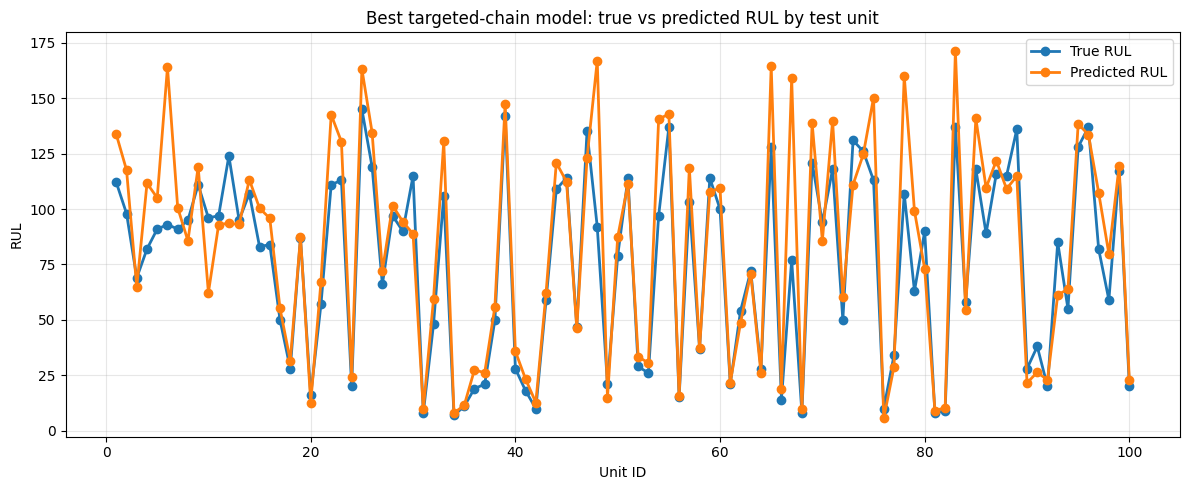

Top-10 largest absolute errors:


,unit_id,true_rul,predicted_rul,error,abs_error
0,67,77,159.093908,82.093908,82.093908
1,48,92,166.983898,74.983898,74.983898
2,6,93,163.987672,70.987672,70.987672
3,78,107,160.213903,53.213903,53.213903
4,54,97,140.541799,43.541799,43.541799
5,75,113,150.193337,37.193337,37.193337
6,65,128,164.504272,36.504272,36.504272
7,79,63,99.164589,36.164589,36.164589
8,83,137,171.441414,34.441414,34.441414
9,10,96,62.284764,-33.715236,33.715236


In [65]:
best_targeted_prediction_df = pd.DataFrame(
    {
        "unit_id": all_agg_window_test_last_rows["unit_id"].to_numpy(),
        "true_rul": y_test_best_targeted.to_numpy(),
        "predicted_rul": y_pred_best_targeted,
        "error": best_targeted_error.to_numpy(),
        "abs_error": best_targeted_abs_error.to_numpy(),
    }
)

plt.figure(figsize=(12, 5))
plt.plot(
    best_targeted_prediction_df["unit_id"],
    best_targeted_prediction_df["true_rul"],
    marker="o",
    linewidth=2,
    label="True RUL",
)
plt.plot(
    best_targeted_prediction_df["unit_id"],
    best_targeted_prediction_df["predicted_rul"],
    marker="o",
    linewidth=2,
    label="Predicted RUL",
)
plt.title("Best targeted-chain model: true vs predicted RUL by test unit")
plt.xlabel("Unit ID")
plt.ylabel("RUL")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Top-10 largest absolute errors:")
display(
    best_targeted_prediction_df.sort_values("abs_error", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

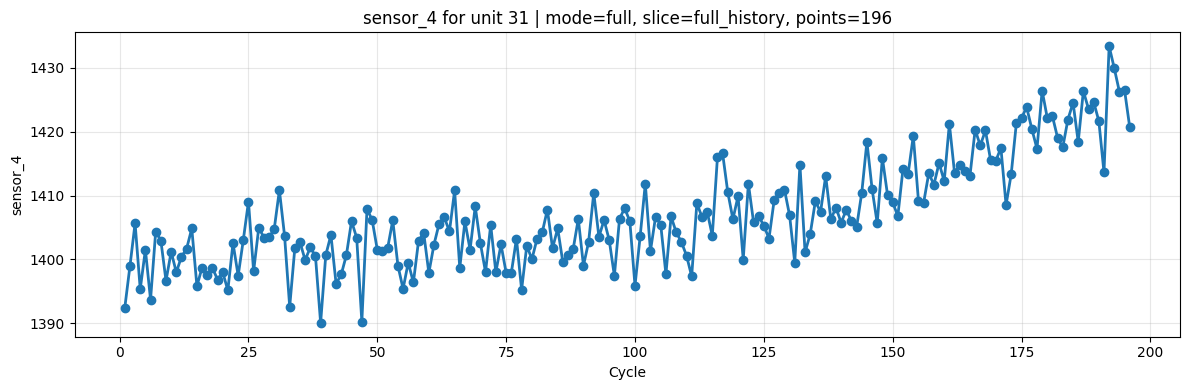

Plotted sensor=sensor_4, unit_id=31, display_mode=full, window_position=middle, plot_window_size=50, points=196


In [66]:
# Универсальный просмотр графика сенсора в стиле Дениса.
# display_mode: "window" - отрезок длины plot_window_size, "full" - вся история выбранного unit.

display_mode = "full"
selected_sensor_for_plot = "sensor_4"
selected_unit_id_for_plot = 31
window_position_for_plot = "middle"
plot_window_size = extended_agg_window_size

if selected_sensor_for_plot not in columns:
    raise ValueError(f"Unknown sensor: {selected_sensor_for_plot}")

if display_mode not in {"window", "full"}:
    raise ValueError("display_mode must be one of: 'window', 'full'")

if plot_window_size <= 0:
    raise ValueError("plot_window_size must be > 0")

if window_position_for_plot not in {"start", "middle", "end"}:
    raise ValueError(
        "window_position_for_plot must be one of: 'start', 'middle', 'end'"
    )

available_units = sorted(test_df["unit_id"].unique())
if selected_unit_id_for_plot is None:
    selected_unit_id_for_plot = int(available_units[0])

if selected_unit_id_for_plot not in available_units:
    raise ValueError(f"unit_id={selected_unit_id_for_plot} is not present in test_df")

unit_history_df = (
    test_df[test_df["unit_id"] == selected_unit_id_for_plot]
    .sort_values("cycle")
    .reset_index(drop=True)
)

history_len = len(unit_history_df)
if history_len == 0:
    raise ValueError("Selected unit has no history")

if display_mode == "full":
    plot_window_df = unit_history_df.copy()
    selected_slice_label = "full_history"
else:
    if history_len <= plot_window_size:
        plot_window_df = unit_history_df.copy()
        selected_slice_label = "full_history_short"
    else:
        if window_position_for_plot == "start":
            plot_window_df = unit_history_df.head(plot_window_size).copy()
        elif window_position_for_plot == "end":
            plot_window_df = unit_history_df.tail(plot_window_size).copy()
        else:
            start_idx = max((history_len - plot_window_size) // 2, 0)
            end_idx = start_idx + plot_window_size
            plot_window_df = unit_history_df.iloc[start_idx:end_idx].copy()

        selected_slice_label = f"window_{window_position_for_plot}"

plt.figure(figsize=(12, 4))
plt.plot(
    plot_window_df["cycle"],
    plot_window_df[selected_sensor_for_plot],
    marker="o",
    linewidth=2,
)
plt.title(
    f"{selected_sensor_for_plot} for unit {selected_unit_id_for_plot} | "
    f"mode={display_mode}, slice={selected_slice_label}, points={len(plot_window_df)}"
)
plt.xlabel("Cycle")
plt.ylabel(selected_sensor_for_plot)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Plotted sensor={selected_sensor_for_plot}, unit_id={selected_unit_id_for_plot}, "
    f"display_mode={display_mode}, window_position={window_position_for_plot}, "
    f"plot_window_size={plot_window_size}, points={len(plot_window_df)}"
)